# OBISClient.jl — querying OBIS from Julia

[OBISClient.jl](https://github.com/dantebertuzzi/OBISClient.jl) is a Julia client for
[OBIS](https://obis.org), the Ocean Biodiversity Information System, a programme of the
Intergovernmental Oceanographic Commission of UNESCO.

> **Not an official OBIS product.** This is an independent, community-maintained client, not
> affiliated with or endorsed by OBIS, the IOC, or UNESCO. The data, the API and the quality
> control behind them are the work of OBIS and its nodes.

This notebook runs real queries against the live API: what a result looks like, the licences
and citations that come attached to it, the quality flags you have to read before using any
of it, and two quick pictures of the data.

Documentation: <https://dantebertuzzi.github.io/OBISClient.jl/stable>

**On Colab, pick the Julia runtime first:** *Runtime ▸ Change runtime type ▸ Julia*. Colab
ships Julia 1.10 LTS with DataFrames and Plots already installed, so the next cell usually
only has to add the client itself.

In [ ]:
using Pkg
Pkg.add(["OBISClient", "DataFrames", "Plots"])

In [ ]:
using OBISClient, DataFrames, Plots, Dates

## A first query

The first argument is a scientific name at any rank; everything else is a keyword. Here the
bivalve *Abra alba*, capped at 500 records.

In [1]:
recs = OBISClient.occurrence("Abra alba"; limit = 500)

OBISTable: 500 records, 62 columns (of 93,300 matching)
  endpoint:  occurrence
  accessed:  2026-09-11
  query:     scientificname=Abra alba
  licenses:  CC-BY-4.0, CC-BY-NC-4.0, CC0-1.0, unknown
  columns:   id, dataset_id, license, license_url, dataset_citation, occurrenceID, eventID, catalogNumber, … (53 more)

## What came back

A result is an `OBISTable`: column-oriented, concretely typed, and Tables.jl-compatible, so it
converts to a `DataFrame`, writes to CSV, or feeds anything else that takes a table.

The schema is the same for every query. OBIS returns only the fields a record has values for,
which means the field set shifts from query to query; this package pins the columns, in the
same order, with the same types, and keeps Darwin Core terms outside that schema per row in an
`extra` column.

In [2]:
df = DataFrame(recs)

first(df[:, [:scientificName, :date_year, :decimalLatitude, :decimalLongitude, :depth, :flags]], 8)

Row,scientificName,date_year,decimalLatitude,decimalLongitude,depth,flags
,String?,Int64?,Float64?,Float64?,Float64?,Set…
1,Abra alba,2015,55.4333,10.8142,missing,"Set([""NO_DEPTH""])"
2,Abra alba,1982,51.7,-5.0357,missing,"Set([""NO_DEPTH""])"
3,Abra alba,1995,55.4915,9.58818,4.6,Set{String}()
4,Abra alba,1997,55.0627,11.6013,13.6,Set{String}()
5,Abra alba,2006,56.1547,10.3187,15.7,Set{String}()
6,Abra alba,1995,56.1547,10.3187,16.0,Set{String}()
7,Abra alba,2010,60.4145,-1.17477,30.0,Set{String}()
8,Abra alba,2020,51.464,3.059,missing,"Set([""NO_DEPTH""])"


`missing` means missing, and collection-valued columns never are: `flags` is an empty
`Set{String}` when nothing was raised, so membership tests need no missing-handling.

The result also knows how many records matched and when you asked — the two things a citation
needs.

In [3]:
meta = OBISClient.metadata(recs)

(retrieved = OBISClient.nrow(recs), matched = meta.total, accessed = meta.accessed)

(retrieved = 500, matched = 93300, accessed = Date("2026-09-11"))

## Licences and citations travel with the result

OBIS data comes with conditions. Licences vary by dataset, and any use has to be cited with
the date it was accessed. One query usually spans several datasets, and the most restrictive
licence governs the whole. Where a provider's rights statement cannot be identified it is
reported as `unknown` — the package does not assume it is permissive.

In [4]:
OBISClient.licenses(recs)

OBISTable: 4 records, 7 columns
  endpoint:  licenses
  accessed:  2026-09-11
  query:     scientificname=Abra alba
  licenses:  CC-BY-4.0, CC-BY-NC-4.0, CC0-1.0, unknown
  columns:   license, datasets, records, permits_redistribution, permits_commercial_use, requires_attribution, url

In [5]:
print(OBISClient.citations(recs; format = :text))

Josefson, A.; Rytter, D.; Department of Bioscience - AU, Denmark; (2015): Danish benthic marine monitoring data from ODAM. [Dataset] (Available: Ocean Biodiversity Information System. Intergovernmental Oceanographic Commission of UNESCO. https://obis.org. Accessed: 2026-09-11)

Stichting ANEMOON. ANEMOON Beach washup monitoring  (SMP) data along the Dutch coastline  collected through citizen science. Version 1.0. stichting ANEMOON. Samplingevent dataset. https://ipt.nlbif.nl/resource?r=anemoon_smp_1977_2024&amp;v=1.0. [Dataset] (Available: Ocean Biodiversity Information System. Intergovernmental Oceanographic Commission of UNESCO. https://obis.org. Accessed: 2026-09-11)

Cooper et al. (2017). RSMP Baseline Dataset. Cefas, UK. V1. doi: https://doi.org/10.14466/CefasDataHub.34 doi:10.14466/CefasDataHub.34. [Dataset] (Available: Ocean Biodiversity Information System. Intergovernmental Oceanographic Commission of UNESCO. https://obis.org. Accessed: 2026-09-11)

ICES Environmental Database 

`format = :bibtex` gives the same thing as BibTeX entries, ready to write to a `.bib` file:

```julia
write("obis-references.bib", OBISClient.citations(recs; format = :bibtex))
```

Cite the datasets you used. Citing this package does not replace that.

## Quality flags, and what a default query hides

The default view is filtered: quality-flagged records are in, records the QC pipeline dropped
are out, and absences are excluded unless you ask for them. So the flags are worth looking at
before anything else.

In [6]:
count(fs -> "ON_LAND" in fs, recs.flags)

78

`statistics_qc` summarises the whole query without retrieving records — a cheap way to see what
you are dealing with. Each flag is defined at [iobis/obis-qc](https://github.com/iobis/obis-qc).

In [7]:
qc = OBISClient.statistics_qc("Abra alba")

qc["flags"]

Dict{String, Any} with 6 entries:
  "NO_COORD"           => 96
  "LAT_OUT_OF_RANGE"   => 8
  "NO_DEPTH"           => 30273
  "DEPTH_EXCEEDS_BATH" => 531
  "LON_OUT_OF_RANGE"   => 8
  "ON_LAND"            => 16443

## Records per year

Record counts measure sampling effort as much as biology. The rise through the late twentieth
century is survey programmes and digitization campaigns; the fall at the recent end is
publication lag, not a decline.

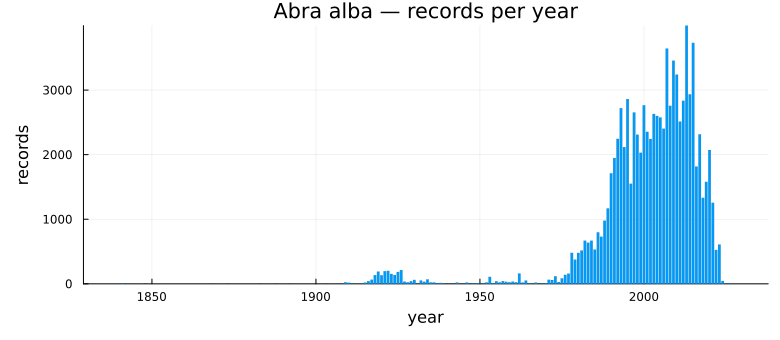

In [8]:
yrs   = OBISClient.statistics_years("Abra alba")
years = [y["year"] for y in yrs if !ismissing(y["year"])]
n     = [y["records"] for y in yrs if !ismissing(y["year"])]

bar(years, n;
    legend = false, linewidth = 0,
    xlabel = "year", ylabel = "records",
    title = "Abra alba — records per year",
    size = (780, 340), left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)

## Where the records are

No map projection here, just longitude against latitude — enough to see what a georeferencing
error looks like. `Abra alba` is marine, so the records flagged `ON_LAND` are somewhere they
cannot have been collected.

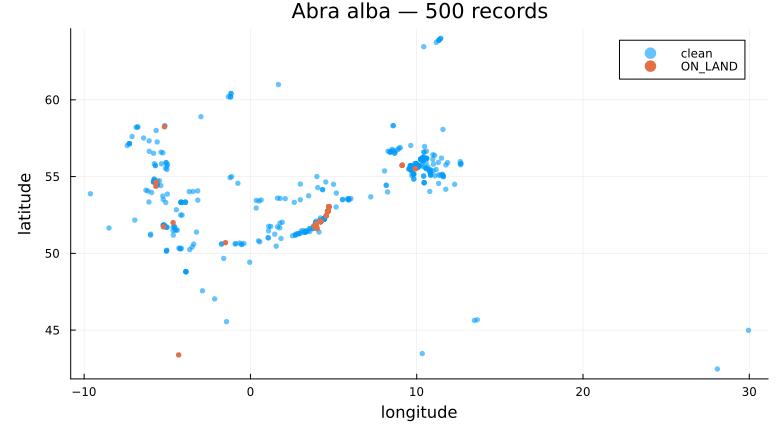

In [9]:
has_xy = [i for i in 1:OBISClient.nrow(recs) if !ismissing(recs.decimalLatitude[i])]
land   = [i for i in has_xy if  ("ON_LAND" in recs.flags[i])]
clean  = [i for i in has_xy if !("ON_LAND" in recs.flags[i])]

scatter(recs.decimalLongitude[clean], recs.decimalLatitude[clean];
        label = "clean", markersize = 3, markerstrokewidth = 0, alpha = 0.6)
scatter!(recs.decimalLongitude[land], recs.decimalLatitude[land];
         label = "ON_LAND", markersize = 3, markerstrokewidth = 0)
plot!(; xlabel = "longitude", ylabel = "latitude",
      title = "Abra alba — 500 records",
      size = (780, 440), left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)

## The other endpoints

Occurrences are one route of several. Which taxa occur in an area, for instance — the polygon
is WKT, which you can draw at [wktmap.com](https://wktmap.com):

In [10]:
OBISClient.checklist(; geometry = "POLYGON ((2.3 51.8, 2.3 51.6, 2.6 51.6, 2.6 51.8, 2.3 51.8))")

OBISTable: 10 records, 28 columns (of 1,703 matching)
  endpoint:  checklist
  accessed:  2026-09-11
  query:     geometry=POLYGON ((2.3 51.8, 2.3 51.6, 2.6 51.6, 2.6 51.8, 2.3 51.8))
  columns:   taxonID, scientificName, scientificNameAuthorship, taxonRank, taxonomicStatus, acceptedNameUsage, acceptedNameUsageID, kingdom, … (19 more)

Or the taxonomy behind a name, matched against WoRMS:

In [11]:
DataFrame(OBISClient.taxon("Abra alba"))[:, [:scientificName, :taxonRank, :taxonomicStatus, :kingdom, :phylum, :class, :family]]

Row,scientificName,taxonRank,taxonomicStatus,kingdom,phylum,class,family
,String?,String?,String?,String?,String?,String?,String?
1,Abra alba,Species,accepted,Animalia,Mollusca,Bivalvia,Semelidae


## Before a big pull

`statistics` and `estimate_size` count the records a query would return without retrieving
them, which makes them the cheap way to size a query first. For large volumes OBIS recommends
its GeoParquet export over the API, and the package will tell you so rather than quietly
switching routes — the two do not return the same thing, since the export is a periodic
snapshot and the API is live.

In [12]:
OBISClient.estimate_size(scientificname = "Abra alba")

93300

## Before you analyse anything

OBIS states the caution itself, and the package will print it in full.

In [13]:
OBISClient.disclaimer()

Appropriate caution is necessary in the interpretation of results derived from OBIS. Users
must recognize that the analysis and interpretation of data require background knowledge
and expertise about marine biodiversity (including ecosystems and taxonomy). Users should
be aware of possible errors, including in the use of species names, geo-referencing, data
handling, and mapping. They should cross check their results for possible errors and
qualify their interpretation of any results accordingly.

Unless data are collected through activities funded by IOC/IODE, neither UNESCO, IOC, IODE,
the OBIS Secretariat, nor its employees or contractors, own the data in OBIS and they take
no responsibility for the quality of data or products based on OBIS, or its use or misuse.



## Where to go next

- [Getting started](https://dantebertuzzi.github.io/OBISClient.jl/stable/getting-started/) — the full filter set and every endpoint
- [Interpreting OBIS data](https://dantebertuzzi.github.io/OBISClient.jl/stable/interpreting/) — what the flags mean and what the default view excludes
- [Licensing and citation](https://dantebertuzzi.github.io/OBISClient.jl/stable/licensing/) — the data policy in practice
- [Large queries](https://dantebertuzzi.github.io/OBISClient.jl/stable/large-queries/) — streaming, resumable pagination, and the bulk export
- [manual.obis.org](https://manual.obis.org) — OBIS's own manual, which this package tries to follow rather than reinvent